# Linked-Read (LEVIATHAN)
Here, we aggregate the visualizations of all size classes and depth treatments for linked-read simulations.

In [25]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(tidyr)

Let's read in the data from the outcomes of the individual size-class assessments and combine them into a single table. Since we'll be comparing this to the long-read data, we should also add a column specifing this is linked-read data and write the entire thing into one file.

In [24]:
lr_inversions <- rbind(
    read.csv("small.sv.assessment", header = T),
    read.csv("medium.sv.assessment", header = T),
    read.csv("large.sv.assessment", header = T),
    read.csv("xl.sv.assessment", header = T)
)
lr_inversions$technology <- "linkedread"
lr_inversions$method <- "leviathan"
if(!file.exists("linkedread.sv.assessment")){
    write.csv(lr_inversions, file = "linkedread.sv.assessment", row.names = F, quote = F)
}
head(lr_inversions)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end,technology,method
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,2L,1,1,0.5,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,leviathan
2,2L,1,1,2.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,leviathan
3,2L,1,1,5.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,leviathan
4,2L,1,1,10.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,leviathan
5,2L,1,1,20.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,leviathan
6,2L,1,1,0.5,1,small,TRUE,hom,false negative,3193196,3214221,linkedread,leviathan


In [45]:
false_positives <- Reduce(
    rbind,
    Map(
        function(x){ read.table(x, header = T)},
        list.files(pattern = "false_positives*",full.names = T)
    )
)
false_positives$assessment <- "false positive"
false_positives$sample <- gsub("pooled", "11", false_positives$sample)
false_positives$sample <- gsub("sample_", "", false_positives$sample)
false_positives$sample <- as.integer(false_positives$sample)
head(false_positives)

,contig,position_start,position_end,sample,depth,size,method,assessment
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
1,3R,5332917,22935558,11,0.5,xl,leviathan,false positive
2,3R,5332917,22935558,2,2.0,xl,leviathan,false positive
3,3R,5332917,22935558,5,2.0,xl,leviathan,false positive
4,3R,5332917,22935558,7,2.0,xl,leviathan,false positive
5,3R,5332917,22935558,1,2.0,xl,leviathan,false positive
6,3R,5332917,22935558,11,2.0,xl,leviathan,false positive


## Summary statistics
We need to know things like:

**Per Sample-Size-Depth**
- average number of identified inversions
- average number of false positives
- recall
- precision
- $F_{1}$ score

The assessment and FP table aren't in the same format, so it would be easier to trim down the bigger table and append the false positive one to it, then do the summary stats.

In [54]:
.inv <- select(lr_inversions, contig, position_start, position_end, sample, depth, size, assessment, method)
head(.inv)

,contig,position_start,position_end,sample,depth,size,assessment,method
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
1,2L,3193196,3214221,11,0.5,small,true positive,leviathan
2,2L,3193196,3214221,11,2.0,small,true positive,leviathan
3,2L,3193196,3214221,11,5.0,small,true positive,leviathan
4,2L,3193196,3214221,11,10.0,small,true positive,leviathan
5,2L,3193196,3214221,11,20.0,small,true positive,leviathan
6,2L,3193196,3214221,1,0.5,small,false negative,leviathan


In [55]:
.inversions <- rbind(
    .inv,
    select(false_positives, contig, position_start, position_end, sample, depth, size, assessment, method)
)
head(.inversions)

,contig,position_start,position_end,sample,depth,size,assessment,method
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
1,2L,3193196,3214221,11,0.5,small,true positive,leviathan
2,2L,3193196,3214221,11,2.0,small,true positive,leviathan
3,2L,3193196,3214221,11,5.0,small,true positive,leviathan
4,2L,3193196,3214221,11,10.0,small,true positive,leviathan
5,2L,3193196,3214221,11,20.0,small,true positive,leviathan
6,2L,3193196,3214221,1,0.5,small,false negative,leviathan


It may be worth collapsing these into averages across size-depth treatments (averaging across samples)

In [88]:
metrics <- group_by(.inversions, size, depth) %>%
    summarize(
        TP = sum(assessment == "true positive"),
        FP = sum(assessment == "false positive"),
        TN = sum(assessment == "true negative"),
        FN = sum(assessment == "false negative")
    )
metrics$precision <- metrics$TP / (metrics$TP + metrics$FP)
metrics$recall <- metrics$TP / (metrics$TP + metrics$FN)
metrics$F1 <- 2 * ((metrics$precision * metrics$recall) / (metrics$precision + metrics$recall))
metrics$depth <- as.factor(metrics$depth)
metrics$size <- factor(metrics$size, ordered = T, levels = c("small", "medium", "large", "xl"))
head(metrics)

`summarise()` has grouped output by 'size'. You can override using the
`.groups` argument.


size,depth,TP,FP,TN,FN,precision,recall,F1
<ord>,<fct>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
large,0.5,3,0,21,64,1,0.04477612,0.08571429
large,2,26,0,21,41,1,0.38805970,0.55913978
large,5,56,0,21,11,1,0.83582090,0.91056911
large,10,67,0,21,0,1,1.00000000,1.00000000
large,20,67,0,21,0,1,1.00000000,1.00000000
medium,0.5,7,0,43,126,1,0.05263158,0.10000000


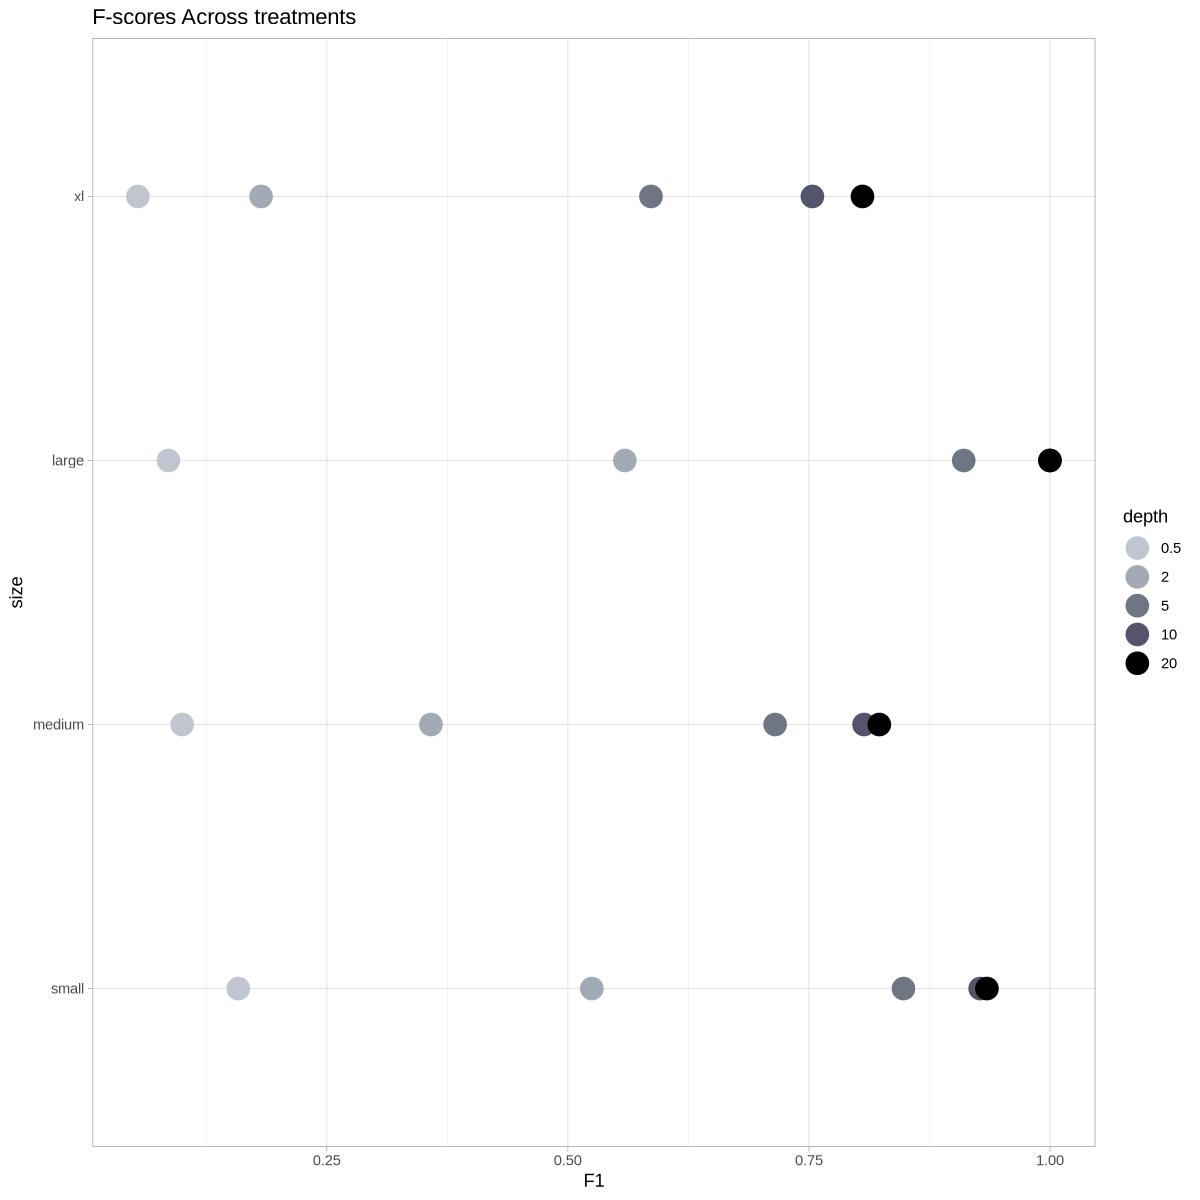

In [89]:
ggplot(metrics, aes(x = F1, y = size, color = depth)) +
    geom_point(size = 6) +
    theme_light() +
    scale_color_manual(values = size_colors) +
    labs(title = "F-scores Across treatments")

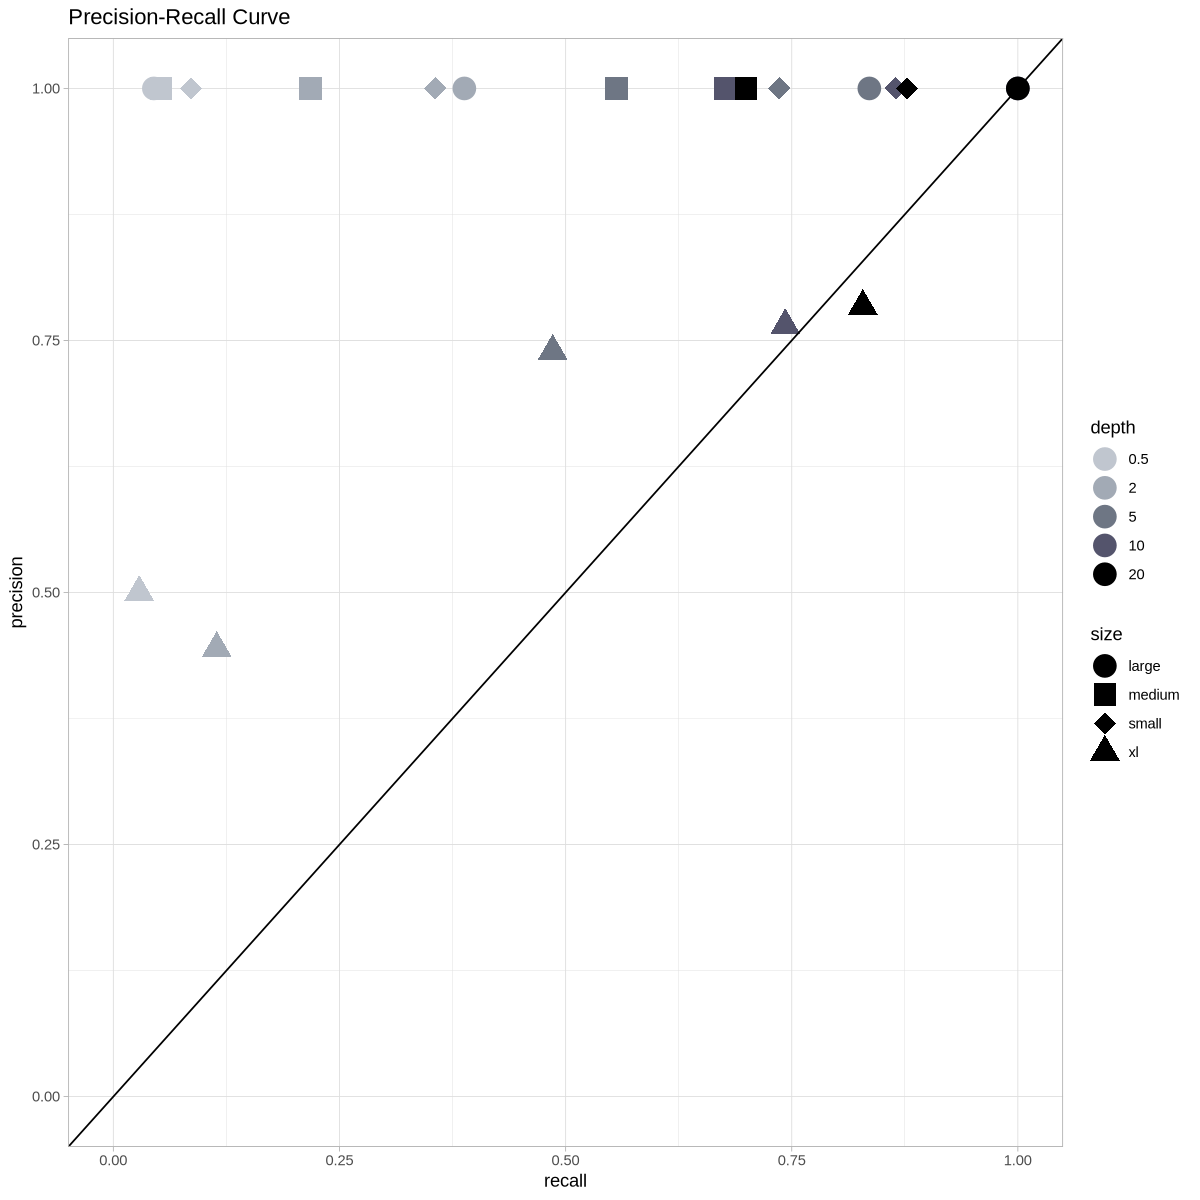

In [82]:
options(warn = -1, repr.plot.width = 10, repr.plot.height = 10)
size_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c",
    "black"
)

ggplot(metrics, aes(x = recall, y = precision, color = depth, shape = size)) +
    geom_point(size = 6) +
    geom_abline(intercept = 0, slope = 1) +
    theme_light() +
    scale_color_manual(values = size_colors) +
    scale_shape_manual(values = c(19,15,18,17)) +
    coord_cartesian(xlim = c(0,1), ylim = c(0,1)) +
    labs(title = "Precision-Recall Curve")

### Single-Sample Detection
Let's visualize what detection looked like across all treatments with respect to false/true positive/negative. Here, we facet rows across depths and show all the size treatments across columns.

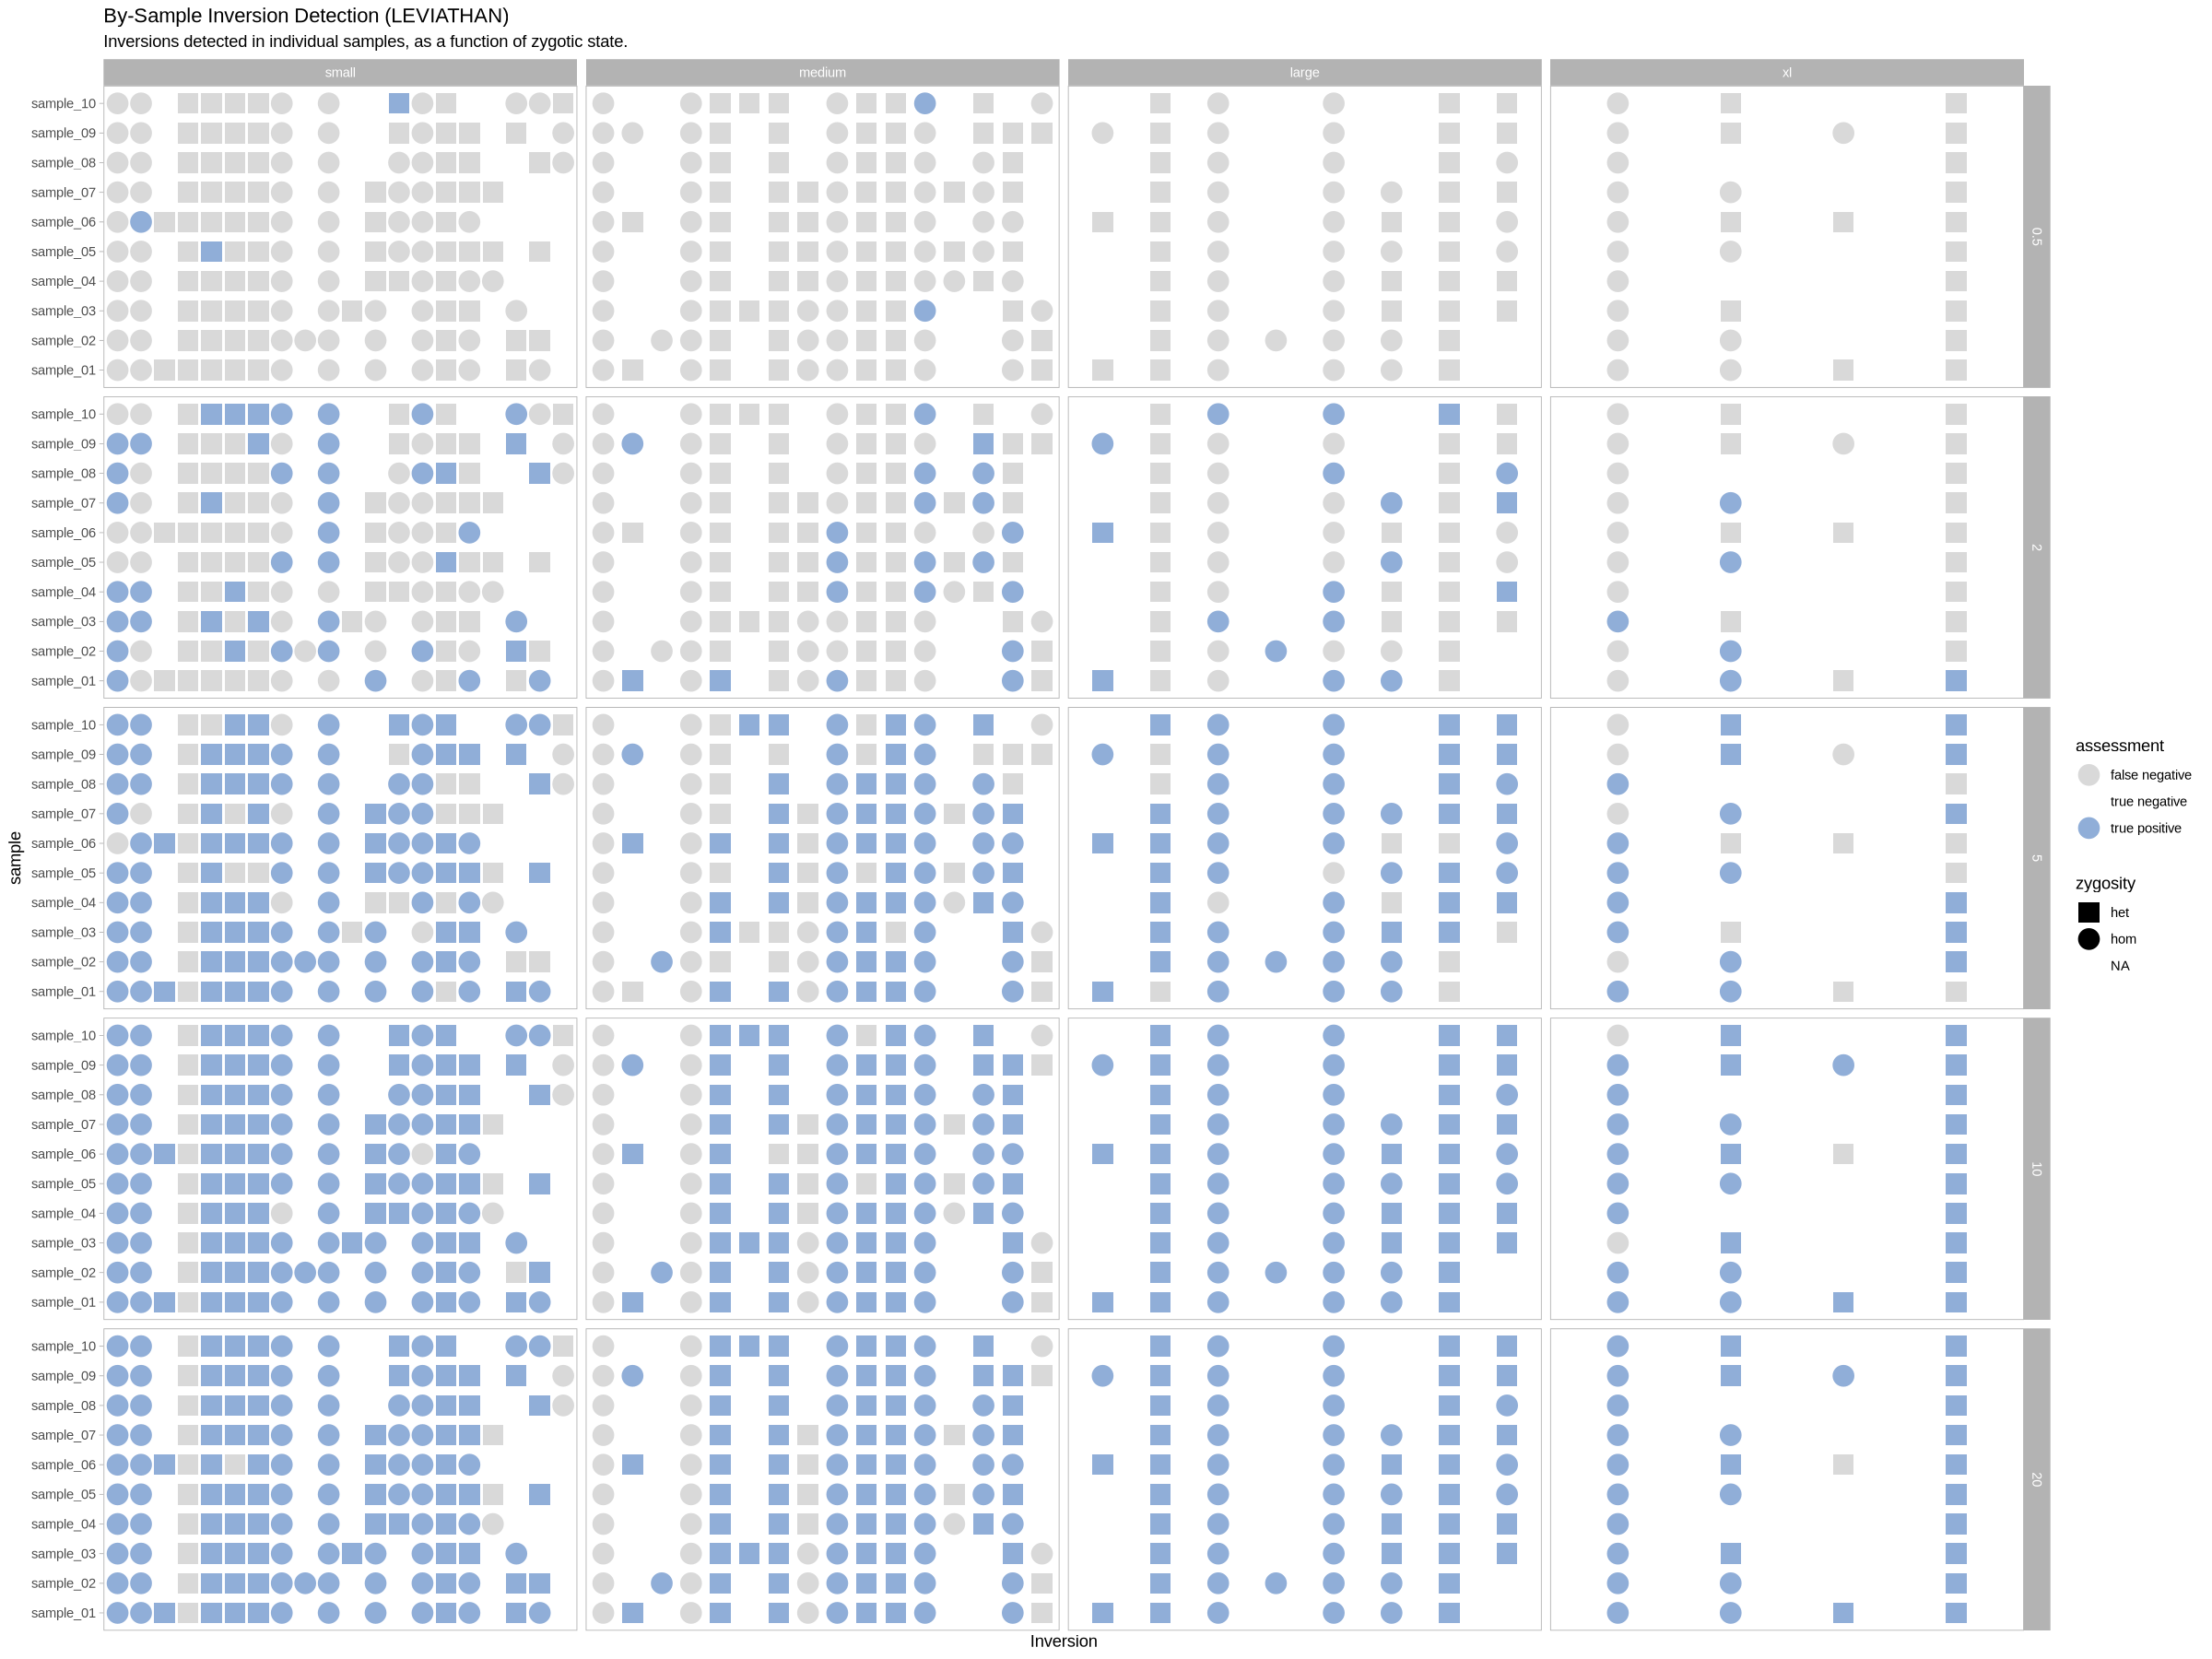

In [7]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 15)
axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
lr_inversions[lr_inversions$sample != 11,] %>%
    ggplot(aes(y = sample, x = id, color = assessment, shape = zygosity)) +
        geom_point(size=6) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection (LEVIATHAN)", subtitle = "Inversions detected in individual samples, as a function of zygotic state.") +
        scale_color_manual(values = c("false negative" = "grey85", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_shape_manual(values = c("hom" = 19, "het" = 15)) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(depth ~ factor(size, levels = c("small", "medium", "large", "xl")), scales = "free_x")


### Pooled Sample Detection 

In [21]:
plot_pools_matrix <- function(data, size_treatment){
    .data <- data[data$sample == 11 & data$size == size_treatment,]
    .data$contig <- gsub("2L", "all hom", .data$contig)
    .data$contig <- gsub("2R", "all het", .data$contig)
    .data$contig <- gsub("3L", "inv common", .data$contig)
    .data$contig <- gsub("3R", "inv rare", .data$contig)
 
    ggplot(.data, aes(y = 1, x = inversion, color = assessment)) +
        geom_point(size=8) +
        theme_light() +
        scale_color_manual(values = c("false negative" = "grey85", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.label.y = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

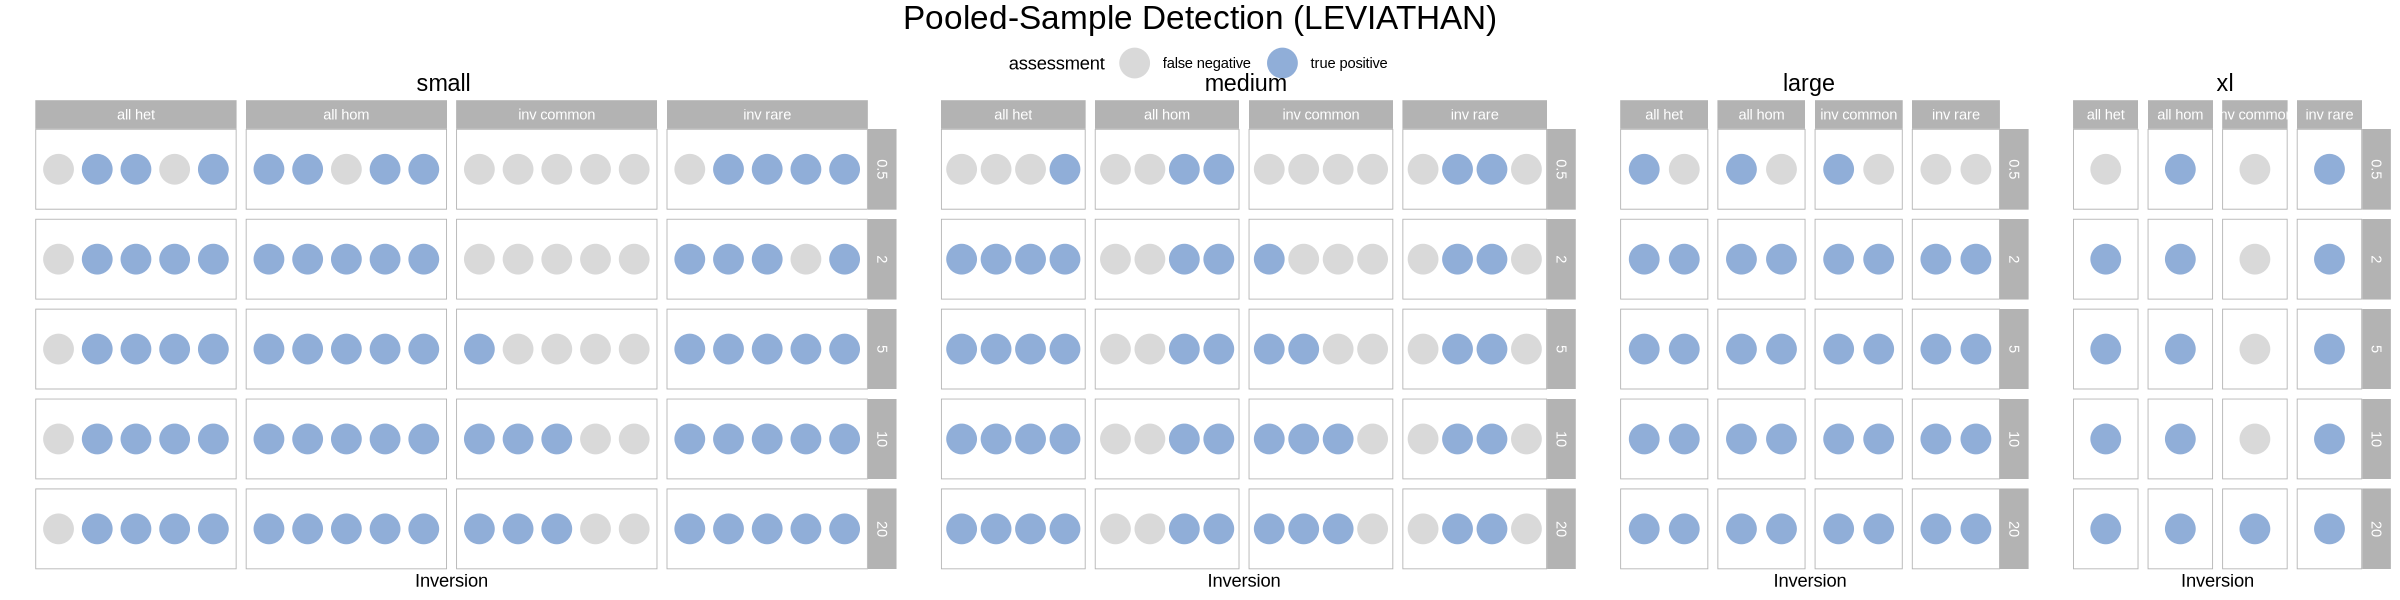

In [23]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 5)
plot <- ggarrange(
    plot_pools_matrix(lr_inversions, "small"),
    plot_pools_matrix(lr_inversions, "medium"),
    plot_pools_matrix(lr_inversions, "large"),
    plot_pools_matrix(lr_inversions, "xl"),
    labels = c("small", "medium", "large", "xl"),
    nrow = 1, ncol = 4, common.legend = T, font.label = c(face = "plain"), legend = "top",
    vjust = 0, label.x = c(0.43, 0.38, 0.38, 0.47),
    widths = c(1, .75, .50, .40)
)
annotate_figure(
    plot,
    top = text_grob(
        "Pooled-Sample Detection (LEVIATHAN)", color = "black", size = 20
        )
)